# GTOC 4 - Reinforcement learning approach

/home/ismag/workspace/tud/bio-inspired/code
/home/ismag/workspace/tud/bio-inspired


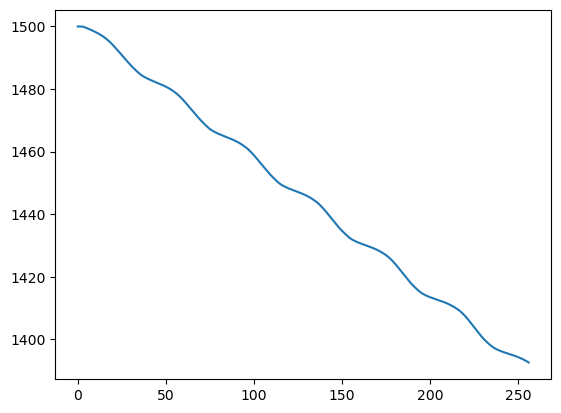

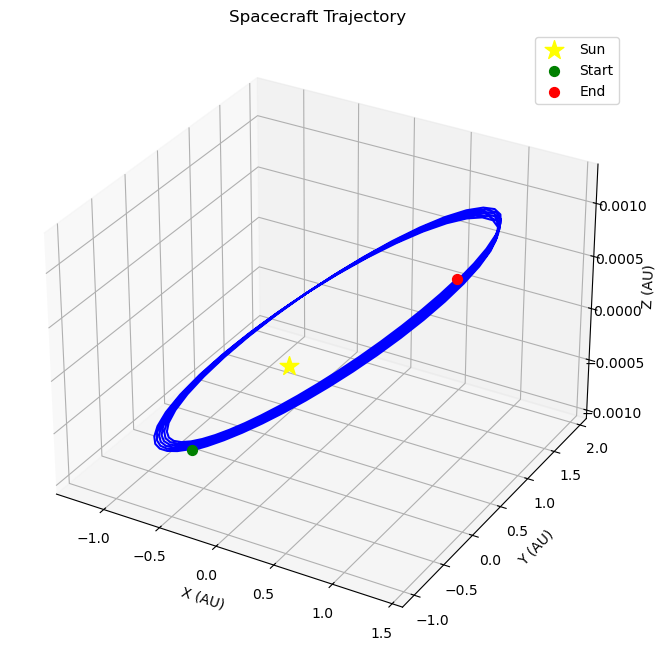

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('code'))
%cd code
%run dynamical_environment.py
%cd ..

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

# locate the results file (path depends on whether script was run from code/ or root)
candidates = ['code/results/PropagationHistory.dat', 'results/PropagationHistory.dat']
dat_file = next((p for p in candidates if os.path.exists(p)), None)
if dat_file is None:
    raise FileNotFoundError("Run the simulation first to generate PropagationHistory.dat")

data = np.loadtxt(dat_file)
# column layout: time(0) | sc x,y,z,vx,vy,vz (1-6) | ast_k x,y,z,vx,vy,vz (7+6k...) | sc_mass (last)
n_cols = data.shape[1]
N = (n_cols - 8) // 6  # infer number of asteroids
print(f"Loaded {dat_file}: {len(data)} timesteps, {N} asteroids")

AU = 1.495978707e11  # m

sc_pos = data[:, 1:4] / AU
ast_positions = [data[:, 7 + 6*k : 10 + 6*k] / AU for k in range(N)]

# subsample to ~100 frames
step = max(1, len(data) // 1000)
sc_f   = sc_pos[::step]
ast_fs = [ap[::step] for ap in ast_positions]

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(0, 0, 0, color='yellow', s=200, marker='*', label='Sun')
ax.plot(sc_pos[:, 0], sc_pos[:, 1], sc_pos[:, 2], 'b-', alpha=0.2, lw=0.5)
for ap in ast_positions:
    ax.plot(ap[:, 0], ap[:, 1], ap[:, 2], 'r-', alpha=0.03, lw=0.3)

sc_dot, = ax.plot([], [], [], 'bo', ms=8, label='Spacecraft')
ast_scatter = ax.scatter(
    [ap[0, 0] for ap in ast_fs],
    [ap[0, 1] for ap in ast_fs],
    [ap[0, 2] for ap in ast_fs],
    c='red', s=10, label=f'Asteroids ({N})'
)

ax.set_xlabel('X (AU)')
ax.set_ylabel('Y (AU)')
ax.set_zlabel('Z (AU)')
ax.legend()
title = ax.set_title('Frame 0')

def update(i):
    sc_dot.set_data(sc_f[i:i+1, 0], sc_f[i:i+1, 1])
    sc_dot.set_3d_properties(sc_f[i:i+1, 2])
    ast_scatter._offsets3d = (
        np.array([ap[i, 0] for ap in ast_fs]),
        np.array([ap[i, 1] for ap in ast_fs]),
        np.array([ap[i, 2] for ap in ast_fs]),
    )
    title.set_text(f'Frame {i+1}/{len(sc_f)}')
    return sc_dot, ast_scatter

anim = animation.FuncAnimation(fig, update, frames=len(sc_f), interval=50)
anim.save('figures/trajectory.gif', writer=PillowWriter(fps=20))
plt.close()
print(f"Saved figures/trajectory.gif")

Loaded code/results/PropagationHistory.dat: 257 timesteps, 500 asteroids
Saved figures/trajectory.gif
